# Анализ эффективности каналов привлечения пользователей развлекательного приложения 

# Шаг 1. Загрузка данных и подготовка их к анализу

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
import seaborn as sns

In [2]:
visits = pd.read_csv('visits_info_short.csv')
orders = pd.read_csv('orders_info_short.csv')
costs = pd.read_csv('costs_info_short.csv')
visits.info()
orders.info()
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   

In [3]:
#переименуем столбцы
visits.columns = ['user_id', 'region', 'device', 'channel', 'session_start', 'session_end']
orders.columns = ['user_id', 'event_dt', 'revenue']
costs.columns = ['dt', 'channel', 'costs']
#преобразуем формат дат
visits['session_start'] = pd.to_datetime(visits['session_start']).dt.date
visits['session_end'] = pd.to_datetime(visits['session_end']).dt.date
orders['event_dt'] = pd.to_datetime(orders['event_dt']).dt.date
costs['dt'] = pd.to_datetime(costs['dt']).dt.date
#проверяем на наличие дубликатов
print('Количество дубликатов в visits', visits.duplicated().sum())
print('Количество дубликатов в orders', orders.duplicated().sum())
print('Количество дубликатов в costs', costs.duplicated().sum())
#удаляем дубликаты и проверяем
orders = orders.drop_duplicates()
print(orders.duplicated().sum())

Количество дубликатов в visits 0
Количество дубликатов в orders 2
Количество дубликатов в costs 0
0


In [4]:
# проверяем данные на наличие пропусков
print('Количество пропусков в visits', visits.isnull().sum())
print('Количество пропусков в orders', orders.isnull().sum())
print('Количество пропусков в costs', costs.isnull().sum())

# проверяем категориальные данные
for column in ['region', 'device', 'channel']:
    print(visits[column].unique())
print(costs['channel'].unique())

Количество пропусков в visits user_id          0
region           0
device           0
channel          0
session_start    0
session_end      0
dtype: int64
Количество пропусков в orders user_id     0
event_dt    0
revenue     0
dtype: int64
Количество пропусков в costs dt         0
channel    0
costs      0
dtype: int64
['United States' 'UK' 'France' 'Germany']
['iPhone' 'Mac' 'Android' 'PC']
['organic' 'TipTop' 'RocketSuperAds' 'YRabbit' 'FaceBoom' 'MediaTornado'
 'AdNonSense' 'LeapBob' 'WahooNetBanner' 'OppleCreativeMedia'
 'lambdaMediaAds']
['FaceBoom' 'MediaTornado' 'RocketSuperAds' 'TipTop' 'YRabbit'
 'AdNonSense' 'LeapBob' 'OppleCreativeMedia' 'WahooNetBanner'
 'lambdaMediaAds']


# Шаг 2. Функции для расчета и анализа LTV, ROI, удержания и конверсии

In [5]:
def get_profiles(sessions, orders, ad_costs):

    # сортируем сессии по ID пользователя и дате привлечения
    # группируем по ID и находим параметры первых посещений
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
         # время первого посещения назовём first_ts
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()  # возвращаем user_id из индекса
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts']
    profiles['month'] = profiles['first_ts'].astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
         # столбец с числом пользователей назовём unique_users
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()  # возвращаем dt и channel из индексов
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    # по дате и каналу привлечения
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    # результаты сохраним в столбец acquisition_cost (CAC)
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавим стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # органические пользователи не связаны с данными о рекламе,
    # поэтому в столбце acquisition_cost у них значения NaN
    # заменим их на ноль, ведь стоимость привлечения равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)
    
    return profiles  # возвращаем профили с CAC

In [6]:
# функция для расчёта удержания

def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time 

In [7]:
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # сохраняем в датафрейм данные пользователей и значения CAC, 
        # добавив параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    )

In [8]:
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу конверсии
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        # считаем сумму с накоплением для каждой строки
        result = result.fillna(0).cumsum(axis = 1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # добавляем размеры когорт в таблицу конверсии
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time 


In [9]:
# функция для сглаживания фрейма

def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

In [10]:
# функция для визуализации LTV и ROI

def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 


In [11]:
# функция для визуализации удержания

def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    
    plt.tight_layout()
    plt.show() 

In [12]:
# функция для визуализации конверсии

def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

# Шаг 3. Исследовательский анализ данных

In [13]:
#получаем профили пользователей
profiles = get_profiles(visits, orders, costs)

#минимальная и максимальная дата привлечения пользователей
min_date = profiles['first_ts'].min()
max_date = profiles['first_ts'].max()
max_orders_date = orders['event_dt'].max()
print(f'Минимальная дата привлечения пользователей - {min_date}')
print(f'Максимальная дата привлечения пользователей - {max_date}')
print(f'Максимальная дата в отчете по продажам - {max_orders_date}')

Минимальная дата привлечения пользователей - 2019-05-01
Максимальная дата привлечения пользователей - 2019-10-27
Максимальная дата в отчете по продажам - 2019-10-31


In [14]:
#строим таблицы для анализа пользователей по странам, используемым устройствам и каналам привлечения
for column in ['region', 'device', 'channel']:
    group_prof = (profiles
                  .groupby(column)
                  .agg({'user_id': 'nunique', 'payer': 'mean'})
                  .sort_values(by='user_id', ascending=False))
    group_prof.columns = ['users_count', 'payer']
    group_prof['share_users'] = group_prof['users_count']/group_prof['users_count'].sum()
    print(f'Анализ пользователей по {column}')
    display(group_prof)                                                                                             

Анализ пользователей по region


,users_count,payer,share_users
region,,,
United States,100002,0.069019,0.666644
UK,17575,0.039829,0.117160
France,17450,0.037994,0.116327
Germany,14981,0.041119,0.099868


Анализ пользователей по device


,users_count,payer,share_users
device,,,
iPhone,54479,0.062079,0.363174
Android,35032,0.058518,0.233534
PC,30455,0.050468,0.203023
Mac,30042,0.063644,0.200269


Анализ пользователей по channel


,users_count,payer,share_users
channel,,,
organic,56439,0.020553,0.376240
FaceBoom,29144,0.122049,0.194283
TipTop,19561,0.096007,0.130400
OppleCreativeMedia,8605,0.027077,0.057364
LeapBob,8553,0.030633,0.057017
WahooNetBanner,8553,0.052964,0.057017
RocketSuperAds,4448,0.079137,0.029652
MediaTornado,4364,0.035747,0.029092
YRabbit,4312,0.038265,0.028745


В базе данных собрана информация по пользователям привлеченным с 1 мая 2019-05 по 27 октября 2019. 


Основная доля пользователей  - это пользователи из США (67% от общего числа пользователей). При этом наибольшая доля платящих пользователей также приходится на США (7%), что существенно превышает доли платящих клиентов в других странах (около 4%).

Чаще всего пользователи использует iPhone (36% от общего числа), доля платящих пользователей iPhone 6,2%. 
Наибольшая доля платящих прользователей использует Mac (6,4%), но данные устройства использует меньше всего  пользователей - только 20% от общего числа. 

Наибольшая доля пользователей приходится на канал organic - 38%, этот канал имеет самую низкую долю платящих пользователей - всего 2%. Второй по количеству пользователей канал привлечения -  FaceBoom. Доля пользователей привлеченных этим каналом составляет - 12%. Этот канал также является лидиром по доле платящих пользователей - 19%.

# Шаг 4. Маркетинг

Суммарные расходы на рекламу составили - 105497$
Средняя стоимость привлечения одного клиента - 1.13$
Структура расходов на рекламу


,channel,costs,acquisition_cost,channel_share
0,TipTop,54751.30,2.799003,0.518983
1,FaceBoom,32445.60,1.113286,0.307549
2,WahooNetBanner,5151.00,0.602245,0.048826
3,AdNonSense,3911.25,1.008054,0.037074
4,OppleCreativeMedia,2151.25,0.250000,0.020392
5,RocketSuperAds,1833.00,0.412095,0.017375
6,LeapBob,1797.60,0.210172,0.017039
7,lambdaMediaAds,1557.60,0.724802,0.014764
8,MediaTornado,954.48,0.218717,0.009047
9,YRabbit,944.22,0.218975,0.008950


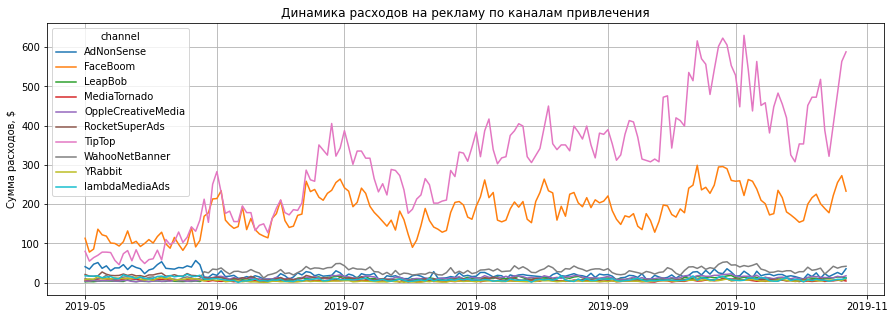

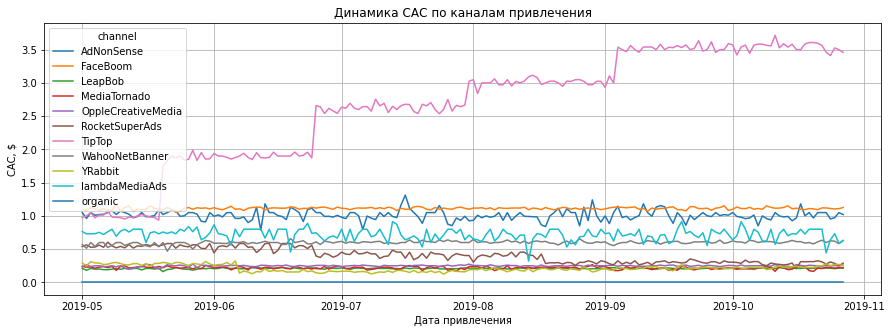

In [15]:
#общие расходы на рекламу в разбивке по каналом привлечения
costs_group = profiles.groupby('channel').agg({'acquisition_cost':['sum', 'mean']})
costs_group.columns = ['costs', 'acquisition_cost']
costs_group = costs_group.sort_values(by='costs', ascending=False).reset_index()
total_costs = costs_group['costs'].sum()
print(f'Суммарные расходы на рекламу составили - {total_costs:.0f}$')

ac_cost_mean = total_costs/profiles.query('channel != "organic"')['user_id'].nunique()
print(f'Средняя стоимость привлечения одного клиента - {ac_cost_mean:.2f}$')

costs_group['channel_share'] = costs_group['costs']/total_costs
print('Структура расходов на рекламу')

display(costs_group)

#расходы на рекламу в разбивке по каналом привлечения и датам
costs.pivot_table(
    index='dt', columns='channel', values='costs', aggfunc='sum'
).plot(grid=True, figsize=(15, 5))
plt.ylabel('Сумма расходов, $')
plt.xlabel('')
plt.title('Динамика расходов на рекламу по каналам привлечения')
plt.show()

#график САС по каналом привлечения в динамике
profiles.pivot_table(
    index='dt', columns='channel', values='acquisition_cost', aggfunc='mean'
).plot(grid=True, figsize=(15, 5))
plt.ylabel('CAC, $')
plt.xlabel('Дата привлечения')
plt.title('Динамика САС по каналам привлечения')
plt.show()

Общие расходы на рекламу за анализуемый период составили 105497$. 52% суммарных расходов занимает TipTop, 31% - FaceBoom, 5% - WahooNetBanner.

В анализируемом периоде наблюдается существенный рост расходов на канал привлечения TipTop, а также рост CAC данного канала привлечения. Стоимость привлечения клиента через TipTop является максимальной среди всех каналов привлечения и значительно превышает САС других каналов.  Средняя стоимость привлечения клиента составляет 1.13$ (это без учета клиентов organic). 

# Шаг 5. Окупаемость рекламы для привлечения пользователей

### Общая окупаемость рекламы

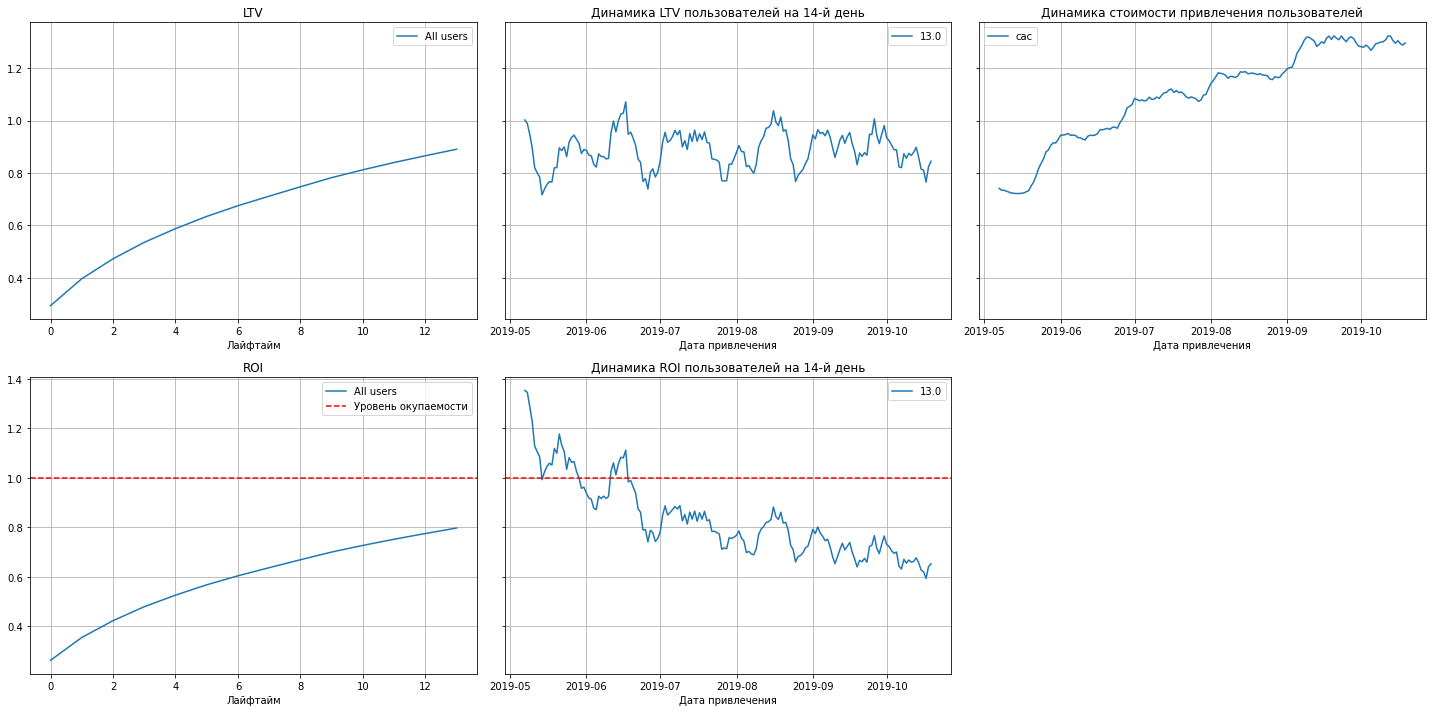

In [16]:
observation_date=datetime(2019, 11, 1).date()
horizon_days=14

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel != "organic"'), orders, observation_date, horizon_days
)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

Затраты на рекламу (без учета клиентов organic) не окупаются - ROI  к концу 14 дней меньше 1.

Динамика ROI пользователей на 14-й день в разбивке по датам привечения отрицательная. Снижение окупаемости начинается с клиентов привлеченных после 1 мая и клиенты привлеченные после 1 июня уже не окупаются. LTV на 14 день колеблется на одном уровне, при резком росте стоимости привлечения пользователей. То есть снижение ROI связано с ростом расходов на привлечение 1 клиента.

### Окупаемость рекламы с разбивкой по устройствам

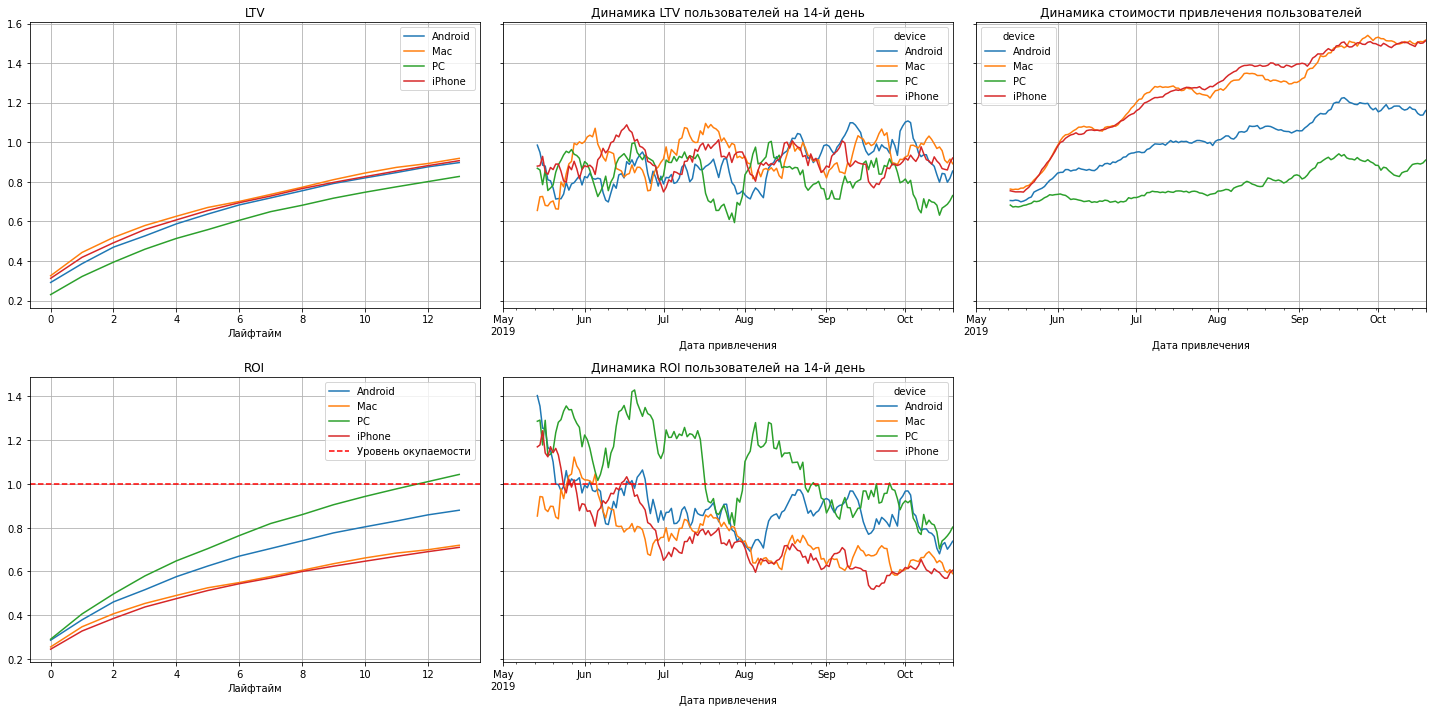

In [17]:
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel != "organic"'), orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

LTV пользователей Android, Mac и iPhone практически идентично, LTV пользователей ПС немного ниже.

Наибольшая стоимость привлечения у пользователей использующих iPhone и Mac. Наименьшая - у пользователей PC. 

Из-за высокой стомости привлечения пользователи Android, Mac и iPhone не окупаются, при этом наихудшая окупаемость к пользователей iPhone и Mac. На 14-ый день окупаются только подозователи ПС. Это связано с более низкой стомостью привлечения данных пользователей. 

Снижение окупаемости в зависимости от даты привлечения наблюдается по всем устройствам. 

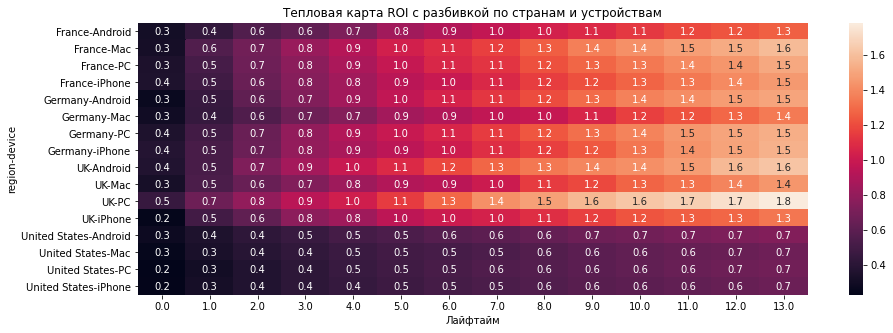

In [18]:
dimensions = ['region', 'device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel != "organic"'), orders, observation_date, horizon_days, dimensions=dimensions
)

roi = roi_grouped.drop(columns=['cohort_size', 'cac'])

plt.figure(figsize=(15, 5))
sns.heatmap(roi, annot=True, fmt='.1f')
plt.title('Тепловая карта ROI с разбивкой по странам и устройствам')
plt.xlabel('Лайфтайм')
plt.show()



  Лучший показатель окупаемости у ПК в Великобритании. В Велибритании показатели окупаемости ПК и Android выше, чем iPhone и Mac. В Германии у всех устройств примерно одинаковые показатели. Во Франции окупаемость iPhone и Mac выше чем у ПК и Android. В США все устройства не окупаются и имеют примерно одинаковые показатели.
    То есть окупаемость пользователей больше зависит не от типа устройств, а от страны пользователя.


### Окупаемость рекламы с разбивкой по странам

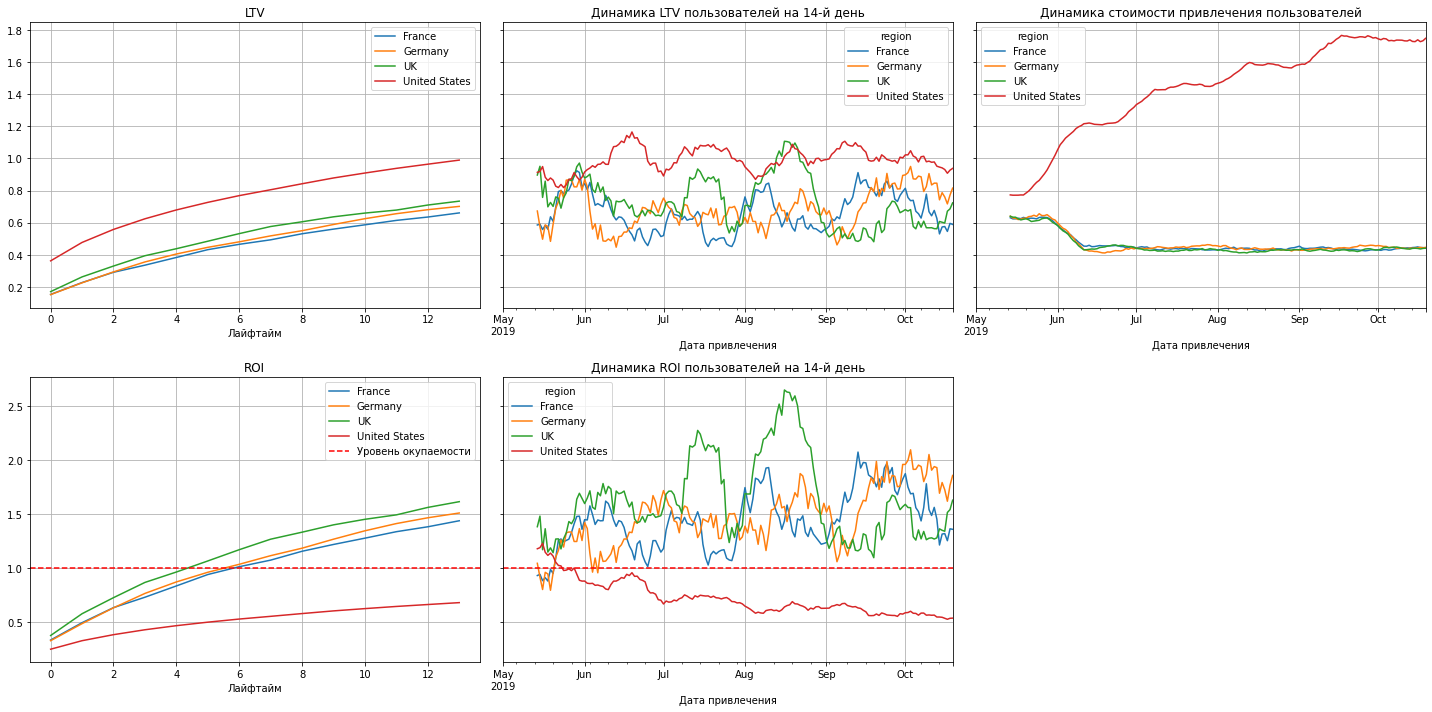

In [19]:
dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel != "organic"'), orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

LTV в США превышает данные других стран, но стоимость привлечения клиентов пользователей из США также выше. При этом наблюдается значительный рост стоимости привлечения пользователей из США, и снижение стоимости привлечения по другим странам.  Пользователи США не окупаются в течении 14 дней, пользователи других стран достигают окупаемости на 5-7 день. 

Динамика окупаемости на 14-ый день в США отрицательная, в других странах нет явной тенденции в снижению или росту. 


### Окупаемость рекламы с разбивкой по рекламным каналам

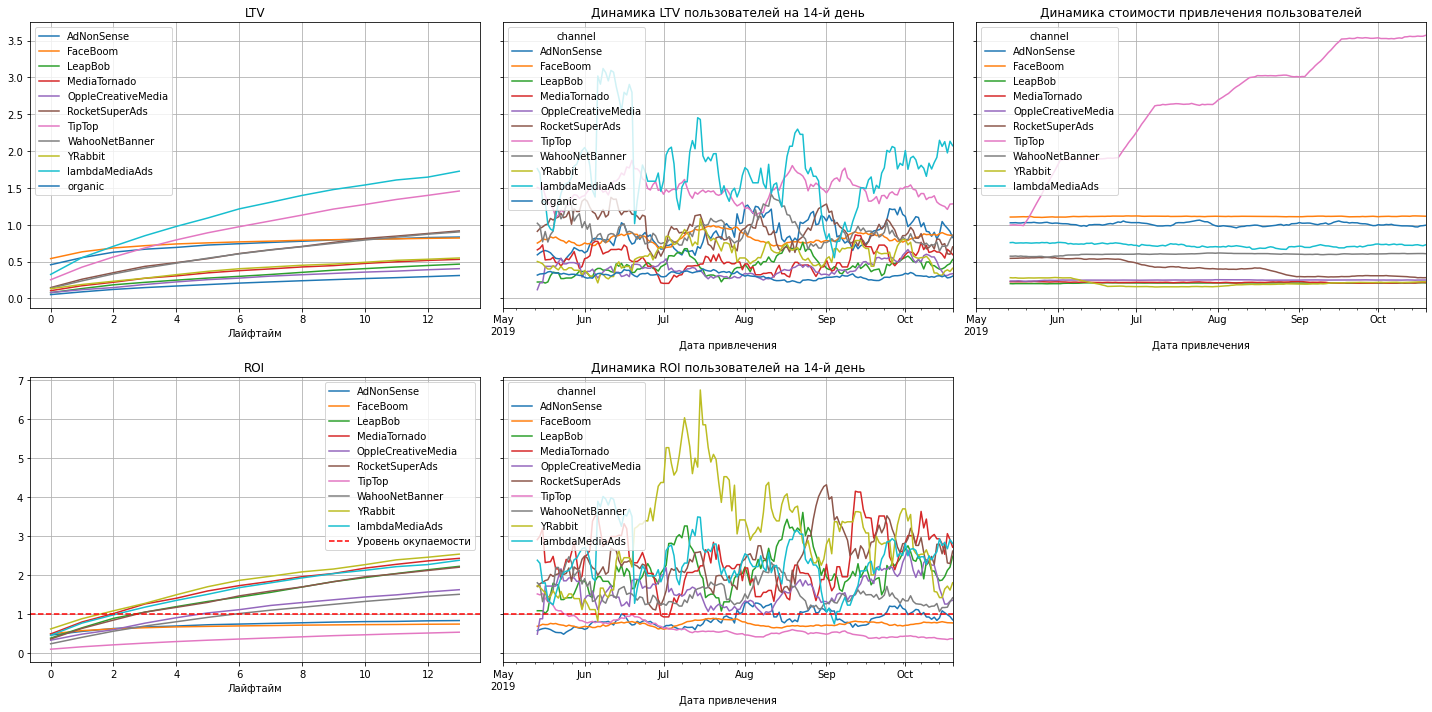

In [20]:
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

Стоимость привлечения пользователей всех каналов за исключением TipTop осталась примерно на том же уровне. По TipTop - стоимость привлечения пользователей увеличилась в 3,5 раза, а так как роста LTV нет, то динамика ROI по данному каналу отрицательная. 

За 14 дней окупаемости не достигают пользователи привлеченные через TipTop, FaceBoom, AdNonSense. Пользователи привлеченные через остальные каналы достигают окупаемости на 3-7 день. 
Наилучшие показатели ROI  у канала - YRabbit, это связано с ростом ROI данного канала по клиентам привлеченным в первой половине июля. 

### Графики конверсии с разбивкой по устройствам, странам, рекламным каналам

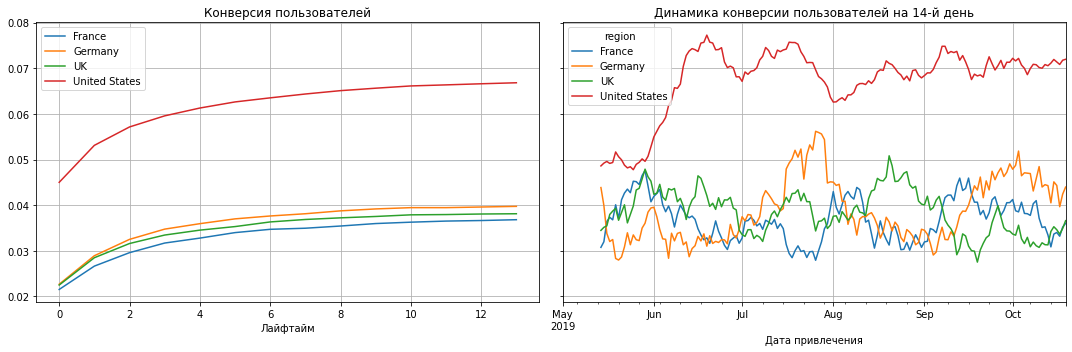

In [21]:
# конверсия по странам
conversion_raw, conversion, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=['region'])

plot_conversion(conversion, conversion_history, horizon_days, window=14)

Конверсия пользователей из США значительно превышает конверсию в других странах и составляет 6.5%, также есть положительная динамика конверсии на 14 день в разрезе дат привлечения клиентов.  

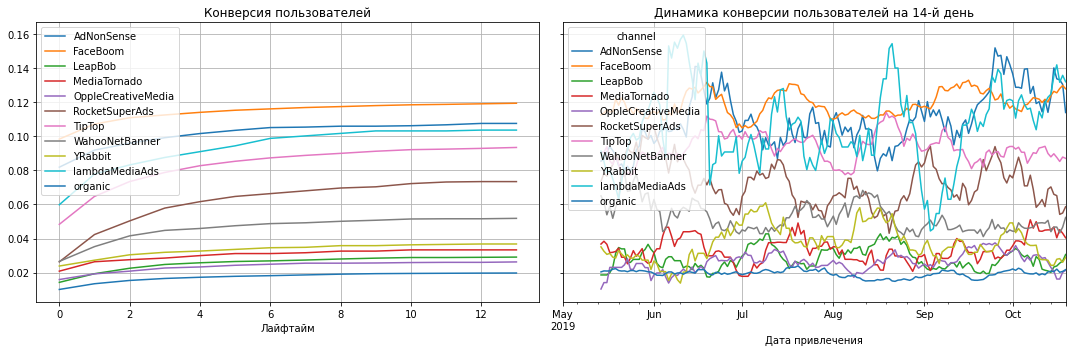

In [22]:
# конверсия по каналам привлечения
сonversion_raw, conversion, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=['channel'])

plot_conversion(conversion, conversion_history, horizon_days, window=14)

Наибольшая конверсия у пользователей привлеченных через FaceBoom, AdNonSense, lambdaMediaAds, TipTop.
Наименьшая - у клиентов organic, OppleCreativeMedia.

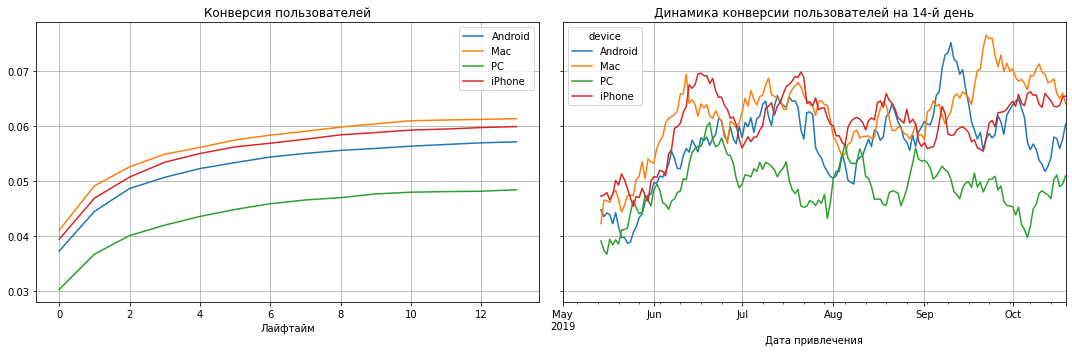

In [23]:
# конверсия по устройствам
сonversion_raw, conversion, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=['device'])

plot_conversion(conversion, conversion_history, horizon_days, window=14)

В разбивке по устройствам - лучшая конверсия у Mac и iPhone. Худший результат у PC. 

###  Графики удержания с разбивкой по устройствам, странам, рекламным каналам

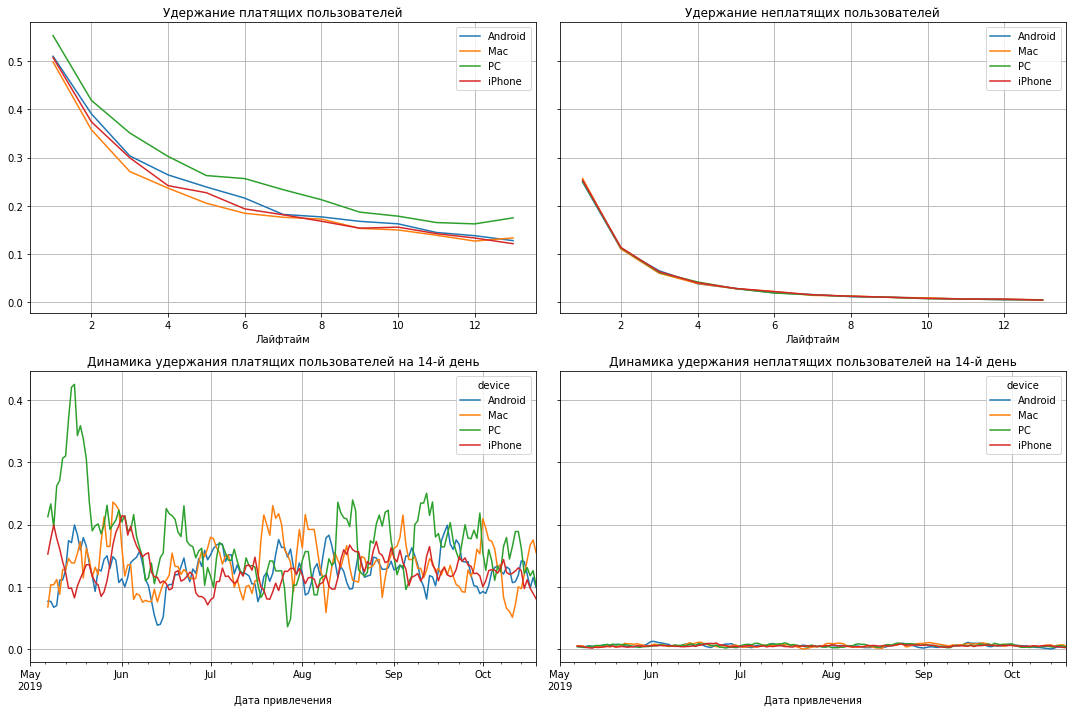

In [24]:
# удержание пользователей по устройствам
retention_raw, retention, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=['device'])

plot_retention(retention, retention_history, horizon_days, window=7)

Удержание платящих пользователей не зависит от устройств пользователей. Удержание платящих и неплатящих пользователей резко снижается и на 14-ый день стремится у неплатящих пользователей к 0, а у платящих к 15%. 

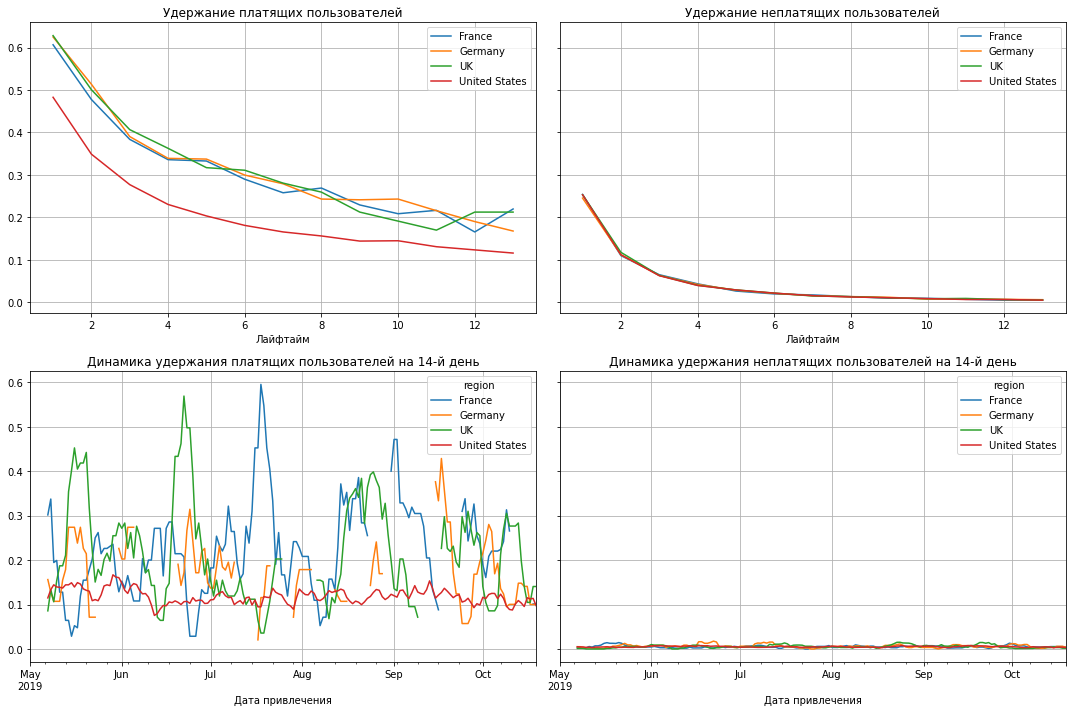

In [25]:
# удержание пользователей по странам
retention_raw, retention, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=['region'])

plot_retention(retention, retention_history, horizon_days, window=7)

Удержание неплатящих пользователей не зависит от страны пользователя. По платящим пользователям - удержание клиентов из США ниже, чем в других странах.

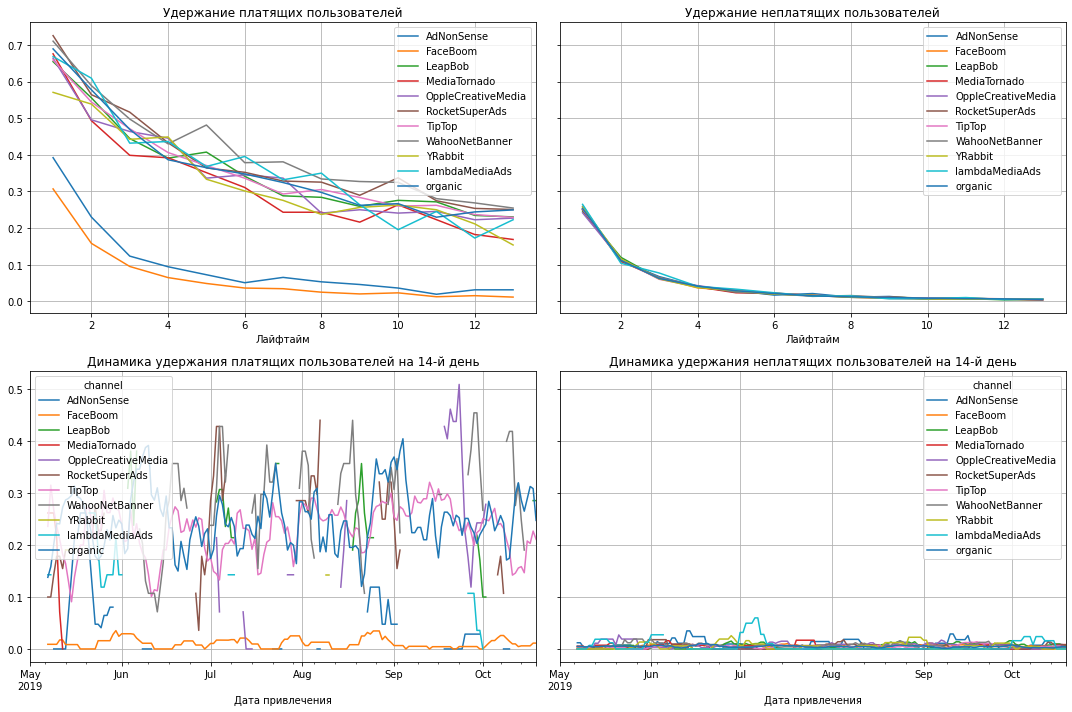

In [26]:
# удержание пользователей по каналам привлечения
retention_raw, retention, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=['channel'])

plot_retention(retention, retention_history, horizon_days, window=7)

Удержание платящих пользователей с каналов FaceBoom, AdNonSense значительно ниже,чем у других каналов. Удержание неплатящих пользователей тажке не зависит от канала привлечения и стремится к 0.

# Шаг 6. Выводы

Причины неэффективности привлечения пользователей:
1. Раходы на привлечение клиентов были увеличены только по одному каналу привлечения - TipTop и только в одной стране - США. Несмотря на то, что конверсия пользователей в США выше, чем в других странах, удержание платящих клиентов ниже. Это привело к тому, что стоимость привлечения клиентов из США и через канал TipTop существенно увеличилась и данных клиенты не окупаются на 14-ый день.
2. FaceBoom - второй по размерам затрат канал привлечения клиентов также не эффективен. Клиенты приходящие с данного канала не окупаются на 14-ый день, при этом удержание данных клиентов стремится к 0 (как у клиентов organic).
3. Клиенты использующие iPhone и Mac не окупаются (это 56% пользователей приложения), при этом у данных клиентов конверсия выше, а удержание примерно как у Android. 
   Но при разбивке окупаемости по странам и устройствам, заментно, что окупаемость пользователей больше зависит не от типа устройств, а от страны пользователя. 


Рекомендации для отдела маркетинга для повышения эффективности:
1. Отказаться от рекламы через FaceBoom
2. Снизить расходы на TipTop до прежнего уровня
3. Увеличить расходы на рекламу по Франции, Германии и Великобритании. Пользователи данных стран окупаются достаточно быстро.
4. Изменить структуру расходов на меркетинг, увеличить расходы на каналы - AdNonSense, lambdaMediaAds, RocketSuoerAds. Данные каналы показывают высокую конверсию и удержание платящих пользователей.


 Возможно нужно обратить внимание на приложение для ПК - эти пользователи имеют самый низкий LTV и их высокая окупаемость объясняется низкой стоимостью привлечения.  Я написала выше, что  при разбивке окупаемости по странам и устройствам, заментно, что окупаемость пользователей больше зависит не от типа устройств, а от страны пользователя.
